In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, Dropout, Dense, Concatenate, GlobalAveragePooling1D

2026-05-02 01:56:30.730203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777686991.125536      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777686991.232545      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777686992.220707      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777686992.220750      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777686992.220753      57 computation_placer.cc:177] computation placer alr

In [2]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d /kaggle/working/ravdess_audio_data/


Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100%|█████████████████████████████████████████| 429M/429M [00:04<00:00, 110MB/s]



In [3]:
dataset_path="/kaggle/working/ravdess_audio_data"

paths = []
emotions = []

emotion_dict = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            emotion = emotion_dict[file.split("-")[2]]
            path = os.path.join(root, file)

            paths.append(path)
            emotions.append(emotion)

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = emotions

print(df.head())
print("Total samples:", len(df))

                                                path    emotion
0  /kaggle/working/ravdess_audio_data/Actor_08/03...      happy
1  /kaggle/working/ravdess_audio_data/Actor_08/03...    fearful
2  /kaggle/working/ravdess_audio_data/Actor_08/03...    fearful
3  /kaggle/working/ravdess_audio_data/Actor_08/03...  surprised
4  /kaggle/working/ravdess_audio_data/Actor_08/03...    fearful
Total samples: 2880


In [4]:
def _compute_features(y, sr=22050):
    hop_length = int(0.010 * sr)
    n_fft = int(0.025 * sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40,
                                hop_length=hop_length, n_fft=n_fft).T

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                         hop_length=hop_length, n_fft=n_fft)
    mel_db = librosa.power_to_db(mel, ref=np.max).T

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12,
                                         hop_length=hop_length, n_fft=n_fft).T

    # ✅ normalization
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)
    chroma = (chroma - np.mean(chroma)) / (np.std(chroma) + 1e-6)

    return mfcc, mel_db, chroma

In [5]:
X_mfcc, X_mel, X_chroma, y_labels = [], [], [], []

for path, emotion in zip(df.path, df.emotion):
    try:
        y, sr = librosa.load(path, sr=22050, duration=4.0)

        # padding signal if short
        if len(y) < sr * 4:
            y = np.pad(y, (0, int(sr*4) - len(y)))

        mfcc, mel, chroma = _compute_features(y, sr)

        X_mfcc.append(mfcc)
        X_mel.append(mel)
        X_chroma.append(chroma)
        y_labels.append(emotion)

    except:
        pass

print("Done extracting original features")

Done extracting original features


In [6]:
X_mfcc = pad_sequences(X_mfcc, maxlen=300, padding='post', truncating='post')
X_mel = pad_sequences(X_mel, maxlen=300, padding='post', truncating='post')
X_chroma = pad_sequences(X_chroma, maxlen=300, padding='post', truncating='post')

In [7]:
le = LabelEncoder()
le.fit(list(emotion_dict.values()))

y_encoded = le.transform(y_labels)
y = to_categorical(y_encoded, num_classes=8)

In [8]:
from sklearn.model_selection import train_test_split

# split كل features مع بعض
X_train_mfcc, X_temp_mfcc, \
X_train_mel, X_temp_mel, \
X_train_chroma, X_temp_chroma, \
y_train, y_temp = train_test_split(
    X_mfcc, X_mel, X_chroma, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
X_val_mfcc, X_test_mfcc, \
X_val_mel, X_test_mel, \
X_val_chroma, X_test_chroma, \
y_val, y_test = train_test_split(
    X_temp_mfcc, X_temp_mel, X_temp_chroma, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [9]:
def add_noise(y):
    return y + 0.005 * np.random.randn(len(y))

def shift(y, sr):
    shift_range = int(sr * 0.2)
    shift = random.randint(-shift_range, shift_range)
    return np.roll(y, shift)

In [10]:
X_mfcc_aug, X_mel_aug, X_chroma_aug, y_aug = [], [], [], []

for path, emotion in zip(df.path, df.emotion):
    try:
        y_audio, sr = librosa.load(path, sr=22050, duration=4.0)

        for aug in [add_noise(y_audio), shift(y_audio, sr)]:
            mfcc, mel, chroma = _compute_features(aug, sr)

            X_mfcc_aug.append(mfcc)
            X_mel_aug.append(mel)
            X_chroma_aug.append(chroma)
            y_aug.append(emotion)

    except:
        pass

# pad
X_mfcc_aug = pad_sequences(X_mfcc_aug, maxlen=300)
X_mel_aug = pad_sequences(X_mel_aug, maxlen=300)
X_chroma_aug = pad_sequences(X_chroma_aug, maxlen=300)

# encode
y_aug_encoded = le.transform(y_aug)
y_aug = to_categorical(y_aug_encoded, num_classes=8)

In [11]:
X_train_mfcc = np.concatenate([X_train_mfcc, X_mfcc_aug])
X_train_mel = np.concatenate([X_train_mel, X_mel_aug])
X_train_chroma = np.concatenate([X_train_chroma, X_chroma_aug])
y_train = np.concatenate([y_train, y_aug])

In [12]:
def build_model(mfcc_shape, mel_shape, chroma_shape, num_classes=8):
    input_mfcc = Input(shape=mfcc_shape, name="mfcc_input")
    input_mel = Input(shape=mel_shape, name="mel_input")
    input_chroma = Input(shape=chroma_shape, name="chroma_input")

    def create_cnn_branch(x, filters, kernel_size, pool_size, dropout_rate):
        x = Conv1D(filters, kernel_size, padding='same')(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)
        x = MaxPooling1D(pool_size=pool_size)(x)
        x = Dropout(dropout_rate)(x)
        return x

    # MFCC branch
    m = create_cnn_branch(input_mfcc, 128, 5, 2, 0.4)
    m = create_cnn_branch(m, 64, 3, 2, 0.3)
    m = create_cnn_branch(m, 32, 3, 2, 0.2)

    # Mel branch
    s = create_cnn_branch(input_mel, 128, 5, 2, 0.4)
    s = create_cnn_branch(s, 64, 3, 2, 0.3)
    s = create_cnn_branch(s, 32, 3, 2, 0.2)

    # Chroma branch
    c = create_cnn_branch(input_chroma, 128, 5, 2, 0.4)
    c = create_cnn_branch(c, 64, 3, 2, 0.3)
    c = create_cnn_branch(c, 32, 3, 2, 0.2)

    # Use GlobalAveragePooling1D instead of Flatten (this is the secret!)
    m_pool = GlobalAveragePooling1D()(m)
    s_pool = GlobalAveragePooling1D()(s)
    c_pool = GlobalAveragePooling1D()(c)

    # Merge branches
    merged = Concatenate()([m_pool, s_pool, c_pool])

    # Fully Connected Layers
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.4)(merged)

    output = Dense(num_classes, activation='softmax')(merged)

    model = Model(inputs=[input_mfcc, input_mel, input_chroma], outputs=output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001) # Increased the Learning Rate a bit to get out of the valley
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

model = build_model(
    mfcc_shape=(300, 40),
    mel_shape=(300, 128),
    chroma_shape=(300, 12),
    num_classes=8
)
model.summary()

I0000 00:00:1777687349.047783      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777687349.053978      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 300, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_input           │ (None, 300, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_input        │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 128)  │     25,728 │ mfcc_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 300, 128)  │     82,048 │ mel_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 300, 128)  │      7,808 │ chroma_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 300, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 128)  │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 150, 128)  │          0 │ re_lu_3[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 150, 128)  │          0 │ re_lu_6[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 150, 128)  │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 150, 128)  │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 150, 128)  │          0 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 64)   │     24,640 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 150, 64)   │     24,640 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 224,168 (875.66 KB)

 Trainable params: 222,824 (870.41 KB)

 Non-trainable params: 1,344 (5.25 KB)

In [13]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    factor=0.5,
    patience=5
)

In [14]:
history = model.fit(
    [X_train_mfcc, X_train_mel, X_train_chroma],
    y_train,
    validation_data=([X_val_mfcc, X_val_mel, X_val_chroma], y_val),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/120


I0000 00:00:1777687359.725930     150 service.cc:152] XLA service 0x7a64fc0ab3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777687359.725968     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777687359.725975     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777687361.056085     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


 12/243 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1476 - loss: 2.3059  

I0000 00:00:1777687372.816998     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


243/243 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.1625 - loss: 2.1200 - val_accuracy: 0.2407 - val_loss: 1.9878 - learning_rate: 1.0000e-04
Epoch 2/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2748 - loss: 1.8794 - val_accuracy: 0.3519 - val_loss: 1.8718 - learning_rate: 1.0000e-04
Epoch 3/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3295 - loss: 1.7857 - val_accuracy: 0.3958 - val_loss: 1.7778 - learning_rate: 1.0000e-04
Epoch 4/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3548 - loss: 1.7179 - val_accuracy: 0.4653 - val_loss: 1.6956 - learning_rate: 1.0000e-04
Epoch 5/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3778 - loss: 1.6477 - val_accuracy: 0.4537 - val_loss: 1.6431 - learning_rate: 1.0000e-04
Epoch 6/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3942 - loss: 1.6007 - val_accuracy: 0.4653 - val_loss: 1.5773 - learning_rate: 1.0000e-04
Epoch 7/120
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accurac

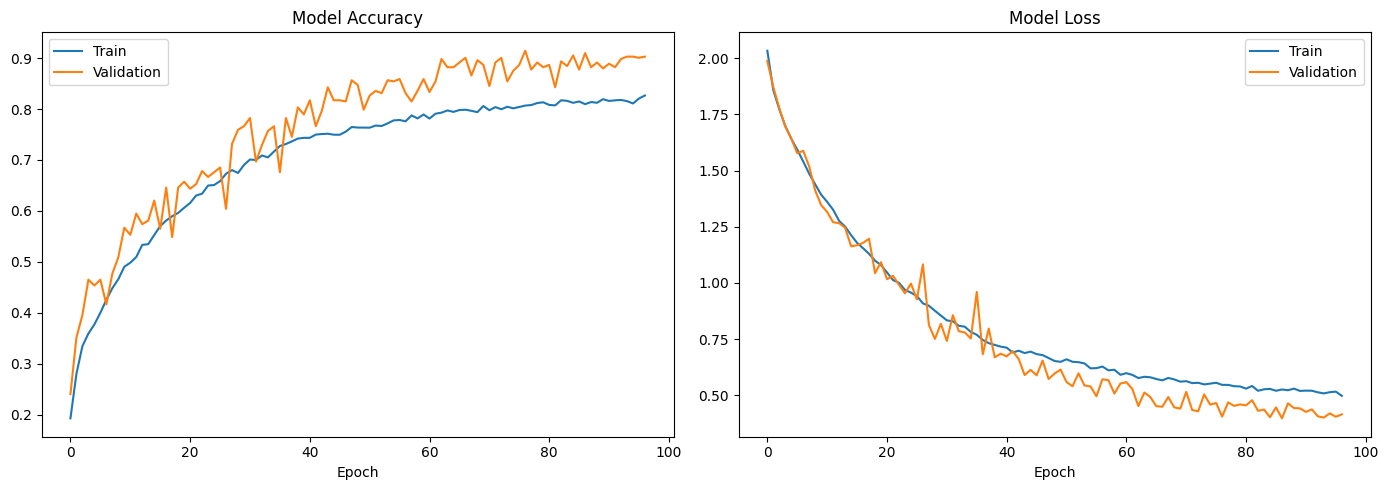

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Accuracy & Loss curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(
    [X_test_mfcc, X_test_mel, X_test_chroma],
    y_test
)

print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9180 - loss: 0.3720
Test Accuracy: 0.9189814925193787


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict([X_test_mfcc, X_test_mel, X_test_chroma])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.98      0.93      0.95        57
           2       0.96      0.90      0.93        58
           3       0.86      0.98      0.92        58
           4       0.88      0.91      0.90        58
           5       0.71      0.93      0.81        29
           6       1.00      0.79      0.88        57
           7       0.93      0.96      0.95        57

    accuracy                           0.92       432
   macro avg       0.91      0.92      0.91       432
weighted avg       0.93      0.92      0.92       432



In [18]:
model.save("emotion_model.h5")

In [19]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)